In [1]:
import pandas as pd
import missingno as msno

In [2]:
fd_df = pd.read_csv("Data/flightdata.csv", index_col=0)
wd_df = pd.read_csv("Data/weather_data.csv", index_col=0)

In [3]:
wd_df["time"]

0            0
1          100
2          200
3          300
4          400
          ... 
263155    1900
263156    2000
263157    2100
263158    2200
263159    2300
Name: time, Length: 263160, dtype: int64

In [4]:
fd_df["CRSDepTime"]

0          2010
1          1450
2          2025
3            52
4          1445
           ... 
1851431    1500
1851432    1820
1851433     955
1851434     630
1851435    1235
Name: CRSDepTime, Length: 1851436, dtype: int64

In [5]:
#rounding scheduled departure time to nearest hour so it aligns with time variable from weather data
new_time = []
for time in fd_df["CRSDepTime"]:
    time = int(time)
    m = time % 100
    if m < 30:
        time = time - m
    elif(m >= 30) :
        time = time + (100 - m)
    if(time == 2400):
        time = 0
    new_time.append(time)
fd_df["NewTime"] = new_time
fd_df[["NewTime", "CRSDepTime"]]

,NewTime,CRSDepTime
0,2000,2010
1,1500,1450
2,2000,2025
3,100,52
4,1500,1445
...,...,...
1851431,1500,1500
1851432,1800,1820
1851433,1000,955
1851434,700,630


In [6]:
#Merge based on airport, time, date
merge_df = pd.merge(fd_df, wd_df,
              how = "inner",
              left_on = ["Origin", "NewTime", "FlightDate"],
              right_on = ["airport","time", "date"])
merge_df.to_csv("Data/flightweatherdata.csv")

Axes(0.125,0.11;0.698618x0.77)
Year               0
Quarter            0
Month              0
DayofMonth         0
FlightDate         0
OriginAirportID    0
Origin             0
DestAirportID      0
Dest               0
CRSDepTime         0
DepTime            0
DepDelayMinutes    0
DepDel15           0
CRSArrTime         0
ArrTime            0
ArrDelayMinutes    0
ArrDel15           0
NewTime            0
windspeedKmph      0
winddirDegree      0
weatherCode        0
precipMM           0
visibility         0
pressure           0
cloudcover         0
DewPointF          0
WindGustKmph       0
tempF              0
WindChillF         0
humidity           0
date               0
time               0
airport            0
dtype: int64


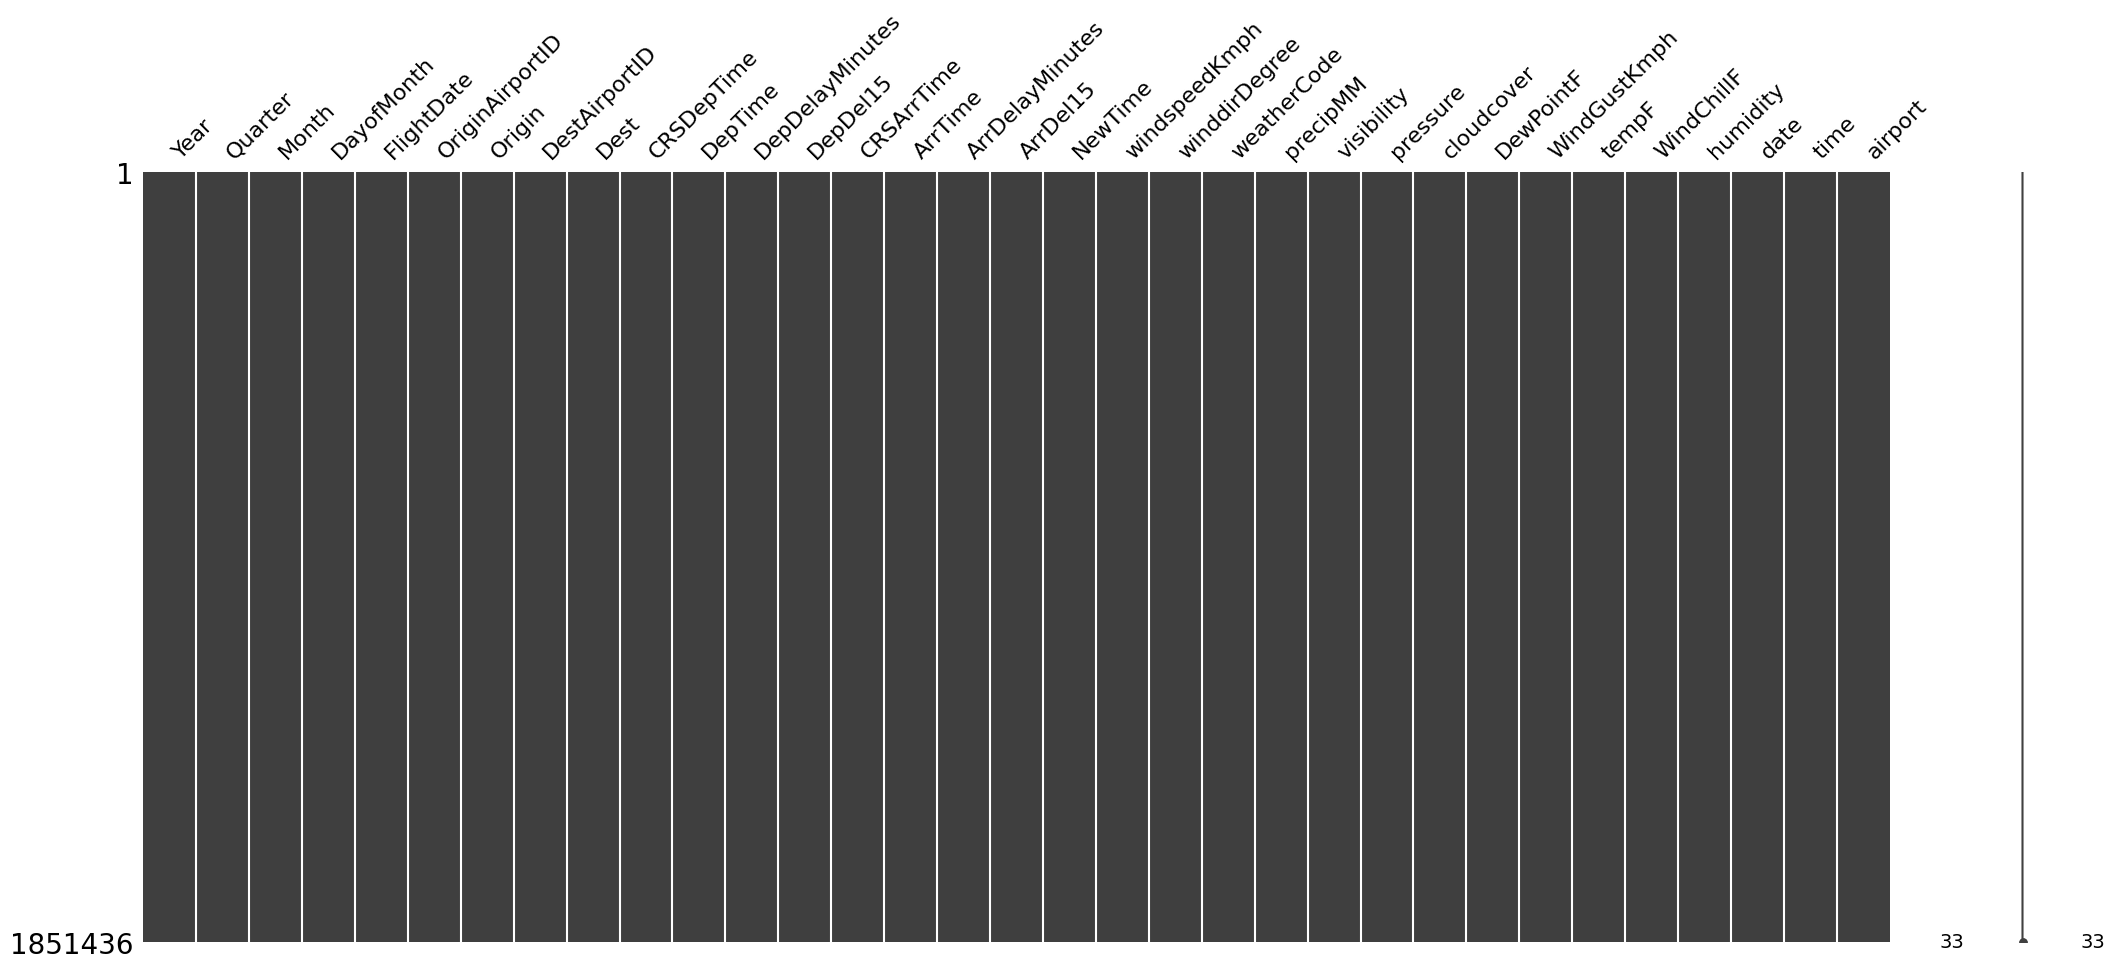

In [7]:
print(msno.matrix(merge_df))
print(merge_df.isnull().sum())